In [28]:
import sys
import os
import json
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 21
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
if 'google.colab' in sys.modules: 
    if not os.path.exists('/content/nlp_course_project'):
        !git clone -b lab-06-branch https://github.com/Karoshi-man/nlp_course_project.git
    
    %cd /content/nlp_course_project
    sys.path.append('/content/nlp_course_project')
    
    FOLDER_ID = '1pIDpBFJ33L9XrldgXEXiAnLRNCs6f0gb'
    
    os.makedirs('/content/nlp_course_project/data', exist_ok=True)
    !gdown --folder https://drive.google.com/drive/folders/{FOLDER_ID} -O /content/nlp_course_project/data/
    
    data_dir = '/content/nlp_course_project/data/processed_v2'

else:
    sys.path.append(os.path.abspath('..'))
    data_dir = '../data/processed_v2'

In [5]:
print(os.listdir('../data/processed_v2'))

['.gitkeep', 'processed_v2.csv']


In [6]:
df = pd.read_csv('../data/processed_v2/processed_v2.csv')
print(df.shape)

(583, 7)


In [8]:
text_column = 'clean_text' if 'clean_text' in df.columns else None
print(f"Для розбиття буде використано колонку: '{text_column}'")

Для розбиття буде використано колонку: 'clean_text'


In [10]:
try:
    nlp = spacy.load("uk_core_news_sm")
except OSError:
    print("Spacy модель не знайдено. Завантажте її командою: !python -m spacy download uk_core_news_sm")
    nlp = None

def split_into_sentences(text):
    if not isinstance(text, str):
        return []
    if nlp:
        doc = nlp(text)
        return [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 15]
    else:
        sents = re.split(r'(?<=[.!?•\n])\s+', text)
        return [s.strip() for s in sents if len(s.strip()) > 15]

In [12]:
sentences_data = []
for idx, row in df.iterrows():
    text = row.get(text_column, '')
    sents = split_into_sentences(text)
    for s in sents:
        sentences_data.append({
            'vacancy_id': row.get('vacancy_id', idx), 
            'sentence': s
        })

df_sentences = pd.DataFrame(sentences_data)

it_keywords = r'\b(?:python|java|c\+\+|c#|\.net|javascript|js|typescript|react|angular|vue|sql|mysql|postgresql|mongodb|aws|gcp|azure|docker|kubernetes|k8s|git|linux|api|django|spring|node\.js|html|css|airflow|spark|hadoop|machine learning|ml|nlp)\b'

# Rule-based розмітка: 1 - технічне речення, 0 - загальний опис
df_sentences['label'] = df_sentences['sentence'].str.contains(it_keywords, flags=re.IGNORECASE, regex=True).astype(int)

print(f"Згенеровано {len(df_sentences)} речень.")
print("\nБаланс класів (0 - Опис, 1 - Технічні вимоги):")
print(df_sentences['label'].value_counts(normalize=True).round(3) * 100)

Згенеровано 8219 речень.

Баланс класів (0 - Опис, 1 - Технічні вимоги):
label
0    76.8
1    23.2
Name: proportion, dtype: float64


In [13]:
X = df_sentences['sentence']
y = df_sentences['label']

# 1. Відділяємо 20% на тестову вибірку (Test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# 2. З решти (80%) беремо 20% на валідацію (Val)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=RANDOM_STATE, stratify=y_temp
)

print("Розміри фінальних вибірок:")
print(f"Train: {X_train.shape[0]} речень ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val:   {X_val.shape[0]} речень ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} речень ({len(X_test)/len(X)*100:.1f}%)")

# Перевірка, що баланс зберігся всюди
print("\nПеревірка стратифікації (відсоток класу 1):")
print(f"Train: {y_train.mean():.3f}")
print(f"Val:   {y_val.mean():.3f}")
print(f"Test:  {y_test.mean():.3f}")

Розміри фінальних вибірок:
Train: 5260 речень (64.0%)
Val:   1315 речень (16.0%)
Test:  1644 речень (20.0%)

Перевірка стратифікації (відсоток класу 1):
Train: 0.232
Val:   0.232
Test:  0.232


In [21]:
# Baseline 1: Стандартна Логістична Регресія + TF-IDF (біграми)
pipeline_b1 = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1, 2), sublinear_tf=True, max_features=10000)),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=500))
])

# Baseline 2: Логістична Регресія з балансуванням класів (через сильний дисбаланс 77/23)
pipeline_b2 = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1, 2), sublinear_tf=True, max_features=10000)),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=500, class_weight='balanced'))
])

print("Pipelines створено. Готово до навчання")

Pipelines створено. Готово до навчання


In [16]:
print("Навчання Baseline 1 (Standard)")
pipeline_b1.fit(X_train, y_train)

print("Навчання Baseline 2 (Balanced)")
pipeline_b2.fit(X_train, y_train)

Навчання Baseline 1 (Standard)
Навчання Baseline 2 (Balanced)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [17]:
# Функція для швидкої оцінки
def evaluate_model(model, X_eval, y_eval, model_name):
    y_pred = model.predict(X_eval)
    acc = accuracy_score(y_eval, y_pred)
    macro_f1 = f1_score(y_eval, y_pred, average='macro')
    return acc, macro_f1

In [18]:
# Оцінка на Validation Set
acc_b1_val, f1_b1_val = evaluate_model(pipeline_b1, X_val, y_val, "Baseline 1")
acc_b2_val, f1_b2_val = evaluate_model(pipeline_b2, X_val, y_val, "Baseline 2")

# Оцінка на Test Set
acc_b1_test, f1_b1_test = evaluate_model(pipeline_b1, X_test, y_test, "Baseline 1")
acc_b2_test, f1_b2_test = evaluate_model(pipeline_b2, X_test, y_test, "Baseline 2")

In [19]:
# Виводимо результати
results_df = pd.DataFrame({
    'Model': ['Baseline 1 (Standard)', 'Baseline 2 (Balanced)'],
    'Val Accuracy': [acc_b1_val, acc_b2_val],
    'Val Macro-F1': [f1_b1_val, f1_b2_val],
    'Test Accuracy': [acc_b1_test, acc_b2_test],
    'Test Macro-F1': [f1_b1_test, f1_b2_test]
})

In [20]:
print("\nПорівняння моделей (Accuracy & Macro-F1):")
display(results_df.round(4))

# Визначаємо переможця по Test Macro-F1
best_model_name = "Baseline 1" if f1_b1_test > f1_b2_test else "Baseline 2"
best_pipeline = pipeline_b1 if f1_b1_test > f1_b2_test else pipeline_b2

print(f"\nНайкраща модель за Macro-F1: {best_model_name}")


Порівняння моделей (Accuracy & Macro-F1):


,Model,Val Accuracy,Val Macro-F1,Test Accuracy,Test Macro-F1
0,Baseline 1 (Standard),0.9346,0.8992,0.9270,0.8849
1,Baseline 2 (Balanced),0.9559,0.9389,0.9599,0.9441



Найкраща модель за Macro-F1: Baseline 2


In [23]:
y_pred_best = best_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=["0 (Опис)", "1 (Технічні вимоги)"]))

                     precision    recall  f1-score   support

           0 (Опис)       0.98      0.97      0.97      1263
1 (Технічні вимоги)       0.90      0.93      0.91       381

           accuracy                           0.96      1644
          macro avg       0.94      0.95      0.94      1644
       weighted avg       0.96      0.96      0.96      1644



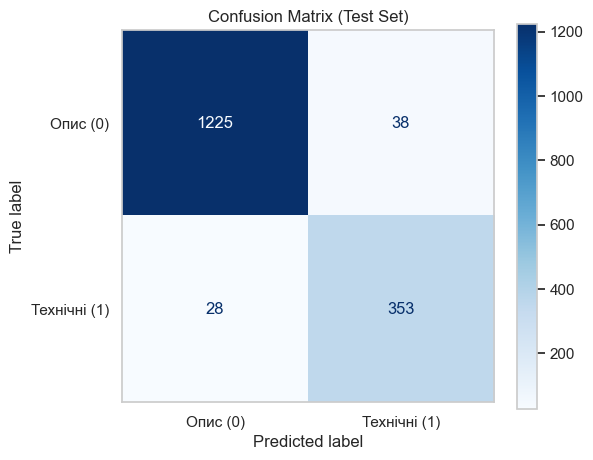

In [24]:
# Побудова Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Опис (0)", "Технічні (1)"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title('Confusion Matrix (Test Set)')
plt.grid(False) # Вимикаємо сітку seaborn для красивої матриці
plt.show()

In [25]:
# Дістаємо векторизатор та саму модель з нашого найкращого пайплайну
vectorizer = best_pipeline.named_steps['tfidf']
clf = best_pipeline.named_steps['clf']
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = clf.coef_[0]
sorted_coef_indices = coefs.argsort()

In [26]:
# Топ-15 для класу 0 (Опис/Вода) - це слова з найбільшими ВІД'ЄМНИМИ вагами
top_negative_indices = sorted_coef_indices[:15]
top_negative_features = feature_names[top_negative_indices]
top_negative_weights = coefs[top_negative_indices]

# Топ-15 для класу 1 (Технічні вимоги) - це слова з найбільшими ПОЗИТИВНИМИ вагами
top_positive_indices = sorted_coef_indices[-15:][::-1]
top_positive_features = feature_names[top_positive_indices]
top_positive_weights = coefs[top_positive_indices]

In [27]:
print("ТОП-15 ознак для класу 1 (Технічні вимоги):")
for feat, weight in zip(top_positive_features, top_positive_weights):
    print(f"{weight:+7.3f} * {feat}")

print("\nТОП-15 ознак для класу 0 (Загальний опис):")
for feat, weight in zip(top_negative_features, top_negative_weights):
    print(f"{weight:+7.3f} * {feat}")

ТОП-15 ознак для класу 1 (Технічні вимоги):
+11.375 * python
+10.824 * ml
 +5.925 * api
 +5.393 * sql
 +3.913 * aws
 +3.897 * machine learning
 +3.887 * machine
 +3.548 * ai ml
 +3.375 * nlp
 +3.352 * learning
 +3.145 * postgresql
 +3.131 * git
 +2.903 * developer
 +2.897 * docker
 +2.796 * airflow

ТОП-15 ознак для класу 0 (Загальний опис):
 -1.949 * компанії
 -1.938 * вакансії компанії
 -1.613 * data engineer
 -1.172 * ми
 -1.152 * вакансії data
 -1.096 * we
 -0.895 * it
 -0.859 * про
 -0.739 * company
 -0.718 * україни
 -0.716 * це
 -0.679 * наша
 -0.648 * is
 -0.629 * our
 -0.629 * senior data


In [29]:
# Error Analysis

errors_mask = y_test != y_pred_best
X_errors = X_test[errors_mask]
y_errors_true = y_test[errors_mask]
y_errors_pred = y_pred_best[errors_mask]

errors_df = pd.DataFrame({
    'sentence': X_errors,
    'true_label': y_errors_true,
    'predicted_label': y_errors_pred
})

# Фіксуємо seed і беремо 15 випадкових помилок
sampled_errors = errors_df.sample(n=15, random_state=RANDOM_STATE)

print(f"Всього помилок: {len(errors_df)} (False Positives: {(y_errors_pred == 1).sum()}, False Negatives: {(y_errors_pred == 0).sum()})\n")

Всього помилок: 66 (False Positives: 38, False Negatives: 28)



In [30]:
print("15 відібраних кейсів для аналізу:\n")

error_list_for_json = []

for idx, (original_index, row) in enumerate(sampled_errors.iterrows(), 1):
    true_lbl = "1 (Технічні)" if row['true_label'] == 1 else "0 (Опис)"
    pred_lbl = "1 (Технічні)" if row['predicted_label'] == 1 else "0 (Опис)"
    
    print(f"Кейс #{idx} [Index ID: {original_index}]")
    print(f"Текст: {row['sentence']}")
    print(f"Gold Label: {true_lbl} | Predicted: {pred_lbl}")
    print("-" * 70)
    
    # Готуємо словник для збереження
    error_list_for_json.append({
        "text_id": int(original_index),
        "text": row['sentence'],
        "gold_label": int(row['true_label']),
        "predicted_label": int(row['predicted_label']),
        "comment": "TODO: додати коментар (overlap класів, noisy label, rare vocabulary)"
    })

15 відібраних кейсів для аналізу:

Кейс #1 [Index ID: 1696]
Текст: A key initiative is a large-scale recommendation system based on a two-tower architecture, deployed on AWS and serving millions of users.
Gold Label: 1 (Технічні) | Predicted: 0 (Опис)
----------------------------------------------------------------------
Кейс #2 [Index ID: 135]
Текст: Strong problem-solving mindset, fast iteration speed, and high ownership.
English B2.
Nice-to-have skills:
Experience with LangChain, LlamaIndex, or similar frameworks.
Familiarity with Pinecone, Weaviate, Chroma, or other vector DBs.
Knowledge of financial data logic or accounting basics.
Understanding of AI safety, guardrails, and hallucination mitigation.
Experience with experimental design, A/B testing, or statistical validation.
Reporting Structure
You will report to the Head of R&D and the Engineering Manager.
Recruitment Process:
Recruiter interview
Technical interview
Test task
Test task review call with the hiring manager (*optio

In [31]:
# Збереження у файл згідно зі структурою репозиторію
os.makedirs("../tests", exist_ok=True)
error_file_path = "../tests/error_cases_lab6.jsonl"

with open(error_file_path, "w", encoding="utf-8") as f:
    for item in error_list_for_json:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print(f"\n15 кейсів успішно збережено у файл: {error_file_path}")


15 кейсів успішно збережено у файл: ../tests/error_cases_lab6.jsonl


## Аналіз помилок (Error Analysis) виявив, що більшість так званих "хибних" спрацьовувань (False Positives) насправді є проблемою Noisy Labels у нашій евристичній розмітці. Наш словник пропустив нові технології (наприклад, LangChain, NoSQL, CI/CD), присвоївши реченням клас 0, проте логістична регресія успішно генералізувала контекст і справедливо віднесла їх до технічних вимог (клас 1). 

## Водночас False Negatives (пропуски навичок) найчастіше трапляються через Context Overlap, коли технічний термін (наприклад, AWS) губиться у довгому реченні, перенасиченому бізнес-лексикою ("initiative", "serving millions"). Також зустрічається проблема змішаного контенту, коли в одному блоці тексту об'єднані як технічні вимоги, так і умови роботи чи опис компанії. Наступним кроком для покращення пайплайну має стати перехід від класифікації цілих речень до точкового вилучення сутностей (NER), що дозволить ігнорувати "воду" безпосередньо навколо знайдених технологій, а також збагачення початкового словника розмітки.

In [32]:
# Автоматична генерація audit_summary_lab6.md
os.makedirs("../docs", exist_ok=True)
audit_file_path = "../docs/audit_summary_lab6.md"

audit_content = f"""# Audit Summary: Lab 6 (TF-IDF + Logistic Baseline)

## 1. Classification Subtask
Оскільки основний напрям проєкту — **В (Extraction / NER)** технічних навичок, допоміжною classification-підзадачею стала бінарна класифікація речень з описів вакансій:
* **Клас 1:** Речення містить технічні навички / технології.
* **Клас 0:** Речення містить загальний опис компанії, умови або "воду".

## 2. Dataset Split
Використано жорсткий спліт зі стратифікацією (збереженням балансу класів):
* **Train:** {X_train.shape[0]} речень
* **Validation:** {X_val.shape[0]} речень
* **Test:** {X_test.shape[0]} речень
* Відсоток класу 1 у вибірках: ~{y_train.mean():.1%}

## 3. Оцінка Baseline-моделей
### Baseline 1 (Standard Logistic Regression)
* **Accuracy (Test):** {acc_b1_test:.4f}
* **Macro-F1 (Test):** {f1_b1_test:.4f}

### Baseline 2 (Balanced Logistic Regression)
* **Accuracy (Test):** {acc_b2_test:.4f}
* **Macro-F1 (Test):** {f1_b2_test:.4f}

## 4. Аналіз результатів
Використання параметра `class_weight='balanced'` дало значний приріст метрики Macro-F1 (з {f1_b1_test:.2f} до {f1_b2_test:.2f}). Це сталось завдяки тому, що модель перестала ігнорувати міноритарний клас (клас технічних навичок, який складав лише 23% від усього датасету).

## 5. Типові помилки (Error Analysis Categories)
Під час аналізу 15 випадкових помилок було виявлено 3 найтиповіші категорії:
1. **Noisy Labels (Неповний словник):** Модель успішно ідентифікує технічні речення з новими або рідкісними технологіями (наприклад, *NoSQL, LangChain*), які були пропущені початковим регулярним виразом.
2. **Context Overlap / Diluted Signal:** Модель помиляється (False Negatives), коли технологія згадується побіжно у довгому реченні, перенасиченому бізнес-лексикою та описом процесів.
3. **Mixed Content:** Речення містить і вимоги, і загальну інформацію (наприклад, обов'язки змішані з умовами праці).

**План виправлення:** Перехід від класифікації речень до точкового вилучення іменованих сутностей (NER) за допомогою контекстуальних моделей, що вирішить проблему змішаного контенту.
"""

with open(audit_file_path, "w", encoding="utf-8") as f:
    f.write(audit_content)

print(f"Файл успішно згенеровано: {audit_file_path}")

Файл успішно згенеровано: ../docs/audit_summary_lab6.md
